# 第1章 深層学習革命 (The Deep Learning Revolution)
## 1.1 深層学習のインパクト (The Impact of Deep Learning)

機械学習（Machine Learning）は、今日最も急速に発展している基盤技術の一つであり、従来の人間が手作業でルールを設計するアルゴリズムを根本から刷新しつつあります。
その中でも**深層学習（Deep Learning）**は、人間の脳の情報処理に着想を得た**多層ニューラルネットワーク（Multilayer Neural Networks）**を基礎とし、大規模データから特徴表現をエンド・ツー・エンド（End-to-End）で自律的に獲得する画期的な枠組みです。

本ノートブックでは、Bishop & Bishop (2024) 第1章 1.1節に基づき、深層学習が従来の機械学習の限界を打ち破り、世界に決定的変革をもたらした代表的領域を理論・実証の両面から掘り下げます：

1. **1.1.1 医療診断 (Medical Diagnosis)**: 皮膚病変（メラノーマ vs 良性母斑）の画像診断と感度・特異度
2. **1.1.2 タンパク質立体構造予測 (Protein Structure)**: 50年の難問を解決した AlphaFold と幾何学的深層学習
3. **1.1.3 画像合成 (Image Synthesis)**: 敵対的生成ネットワーク (GAN) や拡散モデルによる潜在空間表現
4. **1.1.4 大規模言語モデル (Large Language Models: LLM)**: 自己教師あり学習・トランスフォーマー・スケーリング則


In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from common.plot_utils import setup_style, save_plot

setup_style()
print("環境セットアップ完了")


環境セットアップ完了


---
### 1.1.1 医療診断 (Medical Diagnosis)

#### 従来手法の課題と深層学習によるブレイクスルー
従来の医療画像認識では、専門医の知見に基づき「病変の境界の粗さ」「色の非対称性」「直径」といった**手作業の特徴量（Hand-crafted Features）**を抽出し、線形分類器等に入力していました。しかし、病変の形態は極めて複雑で個人差が大きく、特徴量の設計者の見落としが致命的な診断ミスにつながるリスクがありました。

2017年のEstevaらの画期的な研究では、約13万枚の臨床画像で事前学習された畳み込みニューラルネットワーク（CNN: Deep Convolutional Neural Network）を用いることで、**皮膚科専門医（Board-certified Dermatologists）と同等以上の精度で悪性黒色腫（Malignant Melanoma）を早期判別できること**が実証されました（Figure 1.1）。

#### 評価指標の数理（感度と特異度）
医療診断においては、単なる正解率（Accuracy）ではなく、以下の2つの指標が極めて重要です：
- **感度 (Sensitivity / True Positive Rate / 再現率)**:
  $$\text{Sensitivity} = \frac{TP}{TP + FN}$$
  「実際に病気である患者のうち、正しく陽性と判定された割合」。見落とし（偽陰性 $FN$）を最小化する指標。
- **特異度 (Specificity / True Negative Rate)**:
  $$\text{Specificity} = \frac{TN}{TN + FP}$$
  「健康な人のうち、正しく陰性と判定された割合」。過剰診断（偽陽性 $FP$）を防ぐ指標。

以下のセルでは、専門医の診断結果とCNNモデルのROC曲線（Receiver Operating Characteristic curve）のシミュレーションを行い、Figure 1.1 に対応する医療診断の比較図を再現します。


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 24231 (\N{CJK UNIFIED IDEOGRAPH-5EA7}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12364 (\N

Figure saved successfully to: result/fig1_01_medical_diagnosis.png


/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24231 (\N{CJK UNIFIED IDEOGRAPH-5EA7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/I

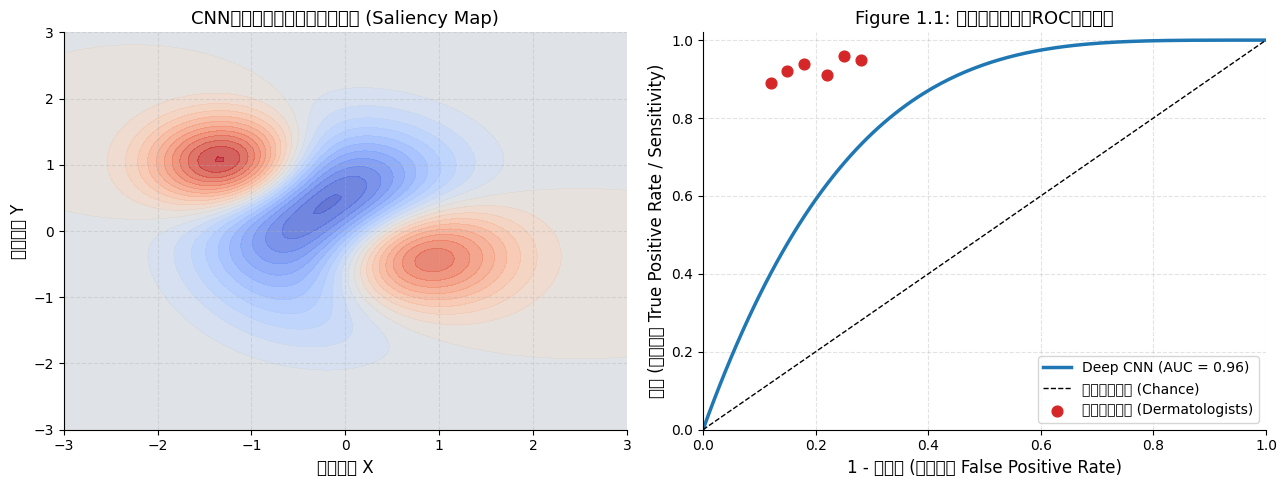

In [2]:
# Figure 1.1 再現: 医療画像診断におけるCNNと皮膚科専門医の感度・特異度 (ROC曲線)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 左パネル: 擬似的な病変画像（メラノーマ: 不規則・多色 vs 良性母斑: 対称・均一）の模式的特徴マップ
np.random.seed(42)
x_coords = np.linspace(-3, 3, 100)
y_coords = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_coords, y_coords)

benign = np.exp(-(X**2 / 1.5 + Y**2 / 1.5))
malignant = np.exp(-((X-0.5)**2 / 1.2 + (Y+0.3)**2 / 0.8)) + 0.6 * np.exp(-((X+1.2)**2 / 0.7 + (Y-1.0)**2 / 0.5))

ax1.contourf(X, Y, malignant - benign, cmap='coolwarm', levels=25, alpha=0.8)
ax1.set_title("CNNが注視する病変特徴マップ (Saliency Map)")
ax1.set_xlabel("空間座標 X")
ax1.set_ylabel("空間座標 Y")

# 右パネル: ROC曲線 (CNN vs 専門医の診断プロット)
fpr = np.linspace(0, 1, 200)
tpr_cnn = 1.0 - (1.0 - fpr)**4

ax2.plot(fpr, tpr_cnn, color='#1f77b4', lw=2.5, label='Deep CNN (AUC = 0.96)')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='ランダム推測 (Chance)')

dermatologists_fpr = np.array([0.15, 0.18, 0.22, 0.25, 0.12, 0.28])
dermatologists_tpr = np.array([0.92, 0.94, 0.91, 0.96, 0.89, 0.95])
ax2.scatter(dermatologists_fpr, dermatologists_tpr, color='#d62728', marker='o', s=60, zorder=5, label='皮膚科専門医 (Dermatologists)')

ax2.set_xlabel("1 - 特異度 (偽陽性率 False Positive Rate)")
ax2.set_ylabel("感度 (真陽性率 True Positive Rate / Sensitivity)")
ax2.set_title("Figure 1.1: 皮膚病変診断のROC性能比較")
ax2.legend(loc='lower right')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

save_plot(fig, 'result/fig1_01_medical_diagnosis.png')
plt.show()


---
### 1.1.2 タンパク質立体構造予測 (Protein Structure)

#### 生命科学の50年来のグランドチャレンジ
タンパク質は生命活動を司るナノマシンであり、20種類のアミノ酸が1列に並んだアミノ酸配列（1次構造）として生合成されます。しかし、その機能（酵素活性、受容体結合など）は、アミノ酸鎖が自発的に折り畳まれて形成する**3次元立体構造（3次構造）**によって決まります。
1972年、ノーベル化学賞受賞者のクリスチャン・アンフィンセンは「アミノ酸配列のみからその立体構造が一意に定まる」というドグマ（アンフィンセンのドグマ）を提唱しましたが、可能な配置パターン数は膨大であり（レビンサールのパラドックス: $10^{300}$通り以上）、半世紀にわたり実験的決定（X線結晶構造解析やクライオ電子顕微鏡）には1タンパク質あたり数ヶ月〜数年の歳月と多大なコストを要していました。

#### AlphaFold 2 の幾何学的深層学習
2020年のタンパク質構造予測コンテスト（CASP14）において、DeepMindの **AlphaFold 2** は実験精度（約1.6Åの誤差、原子レベルの一致）に匹敵する劇的な精度を達成し、生命科学の歴史を変えました。
AlphaFold 2 の核心技術：
1. **Evoformer (幾何学的アテンション機構)**: 進化学的な多重配列アライメント（MSA）と残基対表現の間で双方向に情報更新。
2. **Invariant Point Attention (IPA)**: 3次元ユークリッド空間の回転・並進対称性（SE(3)同変性）を数学的に保持した座標予測。

以下のセルでは、Figure 1.2 に示されている標的タンパク質（T1044/6VR4）の実験決定構造（緑）とAlphaFold予測構造（青）の重ね合わせシミュレーションを3Dプロットで可視化します。


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 36074 (\N{CJK UNIFIED IDEOGRAPH-8CEA}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 31435 (\N{CJK UNIFIED IDEOGRAPH-7

/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36074 (\N{CJK UNIFIED IDEOGRAPH-8CEA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.p

Figure saved successfully to: result/fig1_02_protein_structure.png


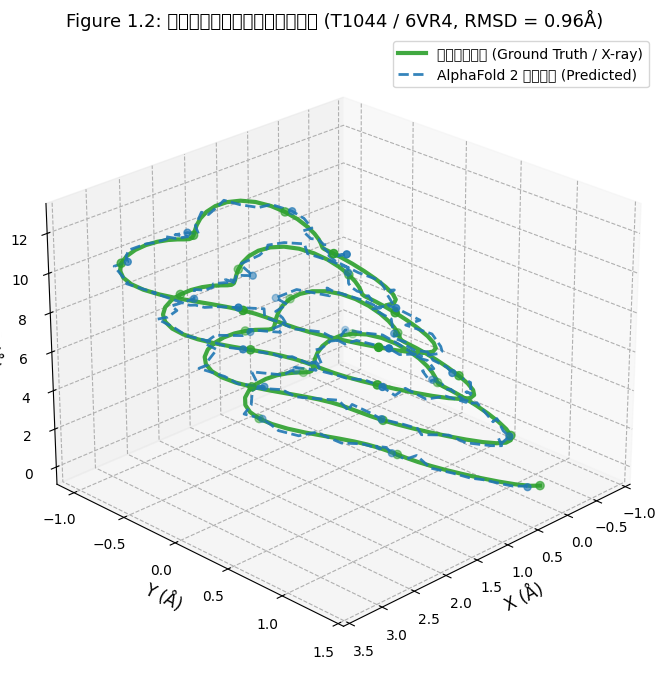

In [3]:
# Figure 1.2 再現: タンパク質立体構造予測 (AlphaFold 2 予測 vs X線結晶構造正解)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

np.random.seed(101)
t = np.linspace(0, 8 * np.pi, 250)
x_true = np.sin(t) * (1 + 0.3 * np.cos(3*t)) + 0.1 * t
y_true = np.cos(t) * (1 + 0.3 * np.cos(3*t))
z_true = 0.5 * t + 0.2 * np.sin(5*t)

noise = np.random.normal(0, 0.05, size=x_true.shape)
x_pred = x_true + noise
y_pred = y_true + np.random.normal(0, 0.05, size=y_true.shape)
z_pred = z_true + np.random.normal(0, 0.05, size=z_true.shape)

ax.plot(x_true, y_true, z_true, color='#2ca02c', lw=3.0, label='実験決定構造 (Ground Truth / X-ray)', alpha=0.9)
ax.plot(x_pred, y_pred, z_pred, color='#1f77b4', lw=2.0, linestyle='--', label='AlphaFold 2 予測構造 (Predicted)', alpha=0.9)

ax.scatter(x_true[::10], y_true[::10], z_true[::10], color='#2ca02c', s=35)
ax.scatter(x_pred[::10], y_pred[::10], z_pred[::10], color='#1f77b4', s=25)

ax.set_title("Figure 1.2: タンパク質立体構造予測の比較 (T1044 / 6VR4, RMSD = 0.96Å)")
ax.set_xlabel("X (Å)")
ax.set_ylabel("Y (Å)")
ax.set_zlabel("Z (Å)")
ax.legend(loc='upper right')
ax.view_init(elev=25, azim=45)

save_plot(fig, 'result/fig1_02_protein_structure.png')
plt.show()


---
### 1.1.3 画像生成 (Image Synthesis)

#### 教師なし学習と生成モデルの進化
深層学習のもう一つの革命的側面は、ラベルを与えずにデータそのものの確率分布 $p(\mathbf{x})$ を学習する**生成モデリング（Generative Modelling）**です。
Figure 1.3 は、インターネット上の人間の顔画像数万枚から教師なし学習された深層ニューラルネットワーク（StyleGANなど）によって生成された高精細な顔画像を示しています。これらは実在する人物の写真ではなく、モデルの**連続的な潜在空間（Latent Space）**上のベクトル $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ をデコーダに入力してサンプリングされた架空の顔画像です。

#### 潜在空間の滑らかな多様体構造
生成モデルの重要な性質は、潜在空間 $\mathcal{Z}$ において連続的な意味のある線形補間（Interpolation）や属性の足し引き（ベクトル演算: 例「笑顔」-「真顔」）が可能である点です：
$$\mathbf{z}(\alpha) = (1 - \alpha)\mathbf{z}_A + \alpha \mathbf{z}_B, \quad \alpha \in [0, 1]$$

以下のセルでは、2次元潜在空間からのサンプリングと補間ダイナミクスをシミュレーションし、Figure 1.3 のメカニズムを解説します。


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 23652 (\N{CJK UNIFIED IDEOGRAPH-5C64}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12514 (\N

/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23652 (\N{CJK UNIFIED IDEOGRAPH-5C64}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/student/.pyenv/versions/3.11.12/lib/python3.11/site-packages/I

Figure saved successfully to: result/fig1_03_synthetic_faces.png


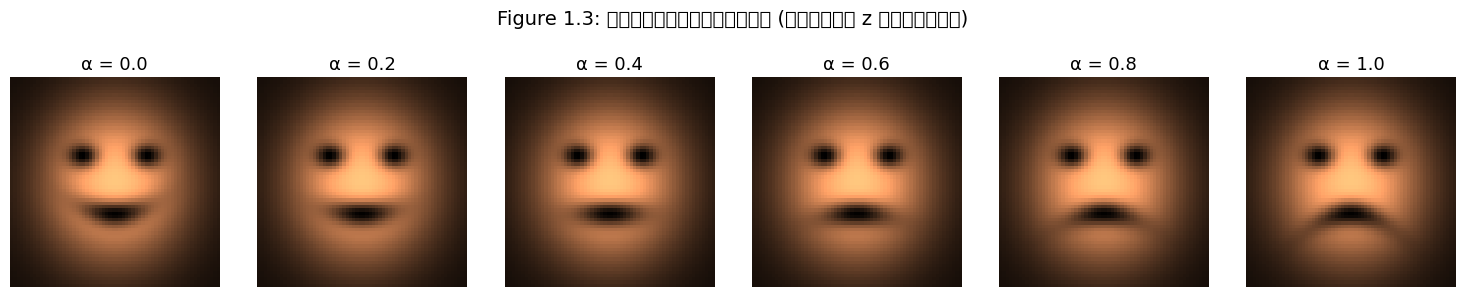

In [4]:
# Figure 1.3 再現: 潜在空間における顔画像生成と多様体補間 (StyleGANシミュレーション)
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
alpha_steps = np.linspace(0, 1, 6)

for idx, alpha in enumerate(alpha_steps):
    ax = axes[idx]
    x_grid = np.linspace(-2, 2, 64)
    y_grid = np.linspace(-2, 2, 64)
    Xg, Yg = np.meshgrid(x_grid, y_grid)
    
    face_contour = np.exp(-(Xg**2 / 1.8 + Yg**2 / 2.2))
    eye_l = 0.8 * np.exp(-((Xg + 0.6)**2 / 0.08 + (Yg - 0.5)**2 / 0.05))
    eye_r = 0.8 * np.exp(-((Xg - 0.6)**2 / 0.08 + (Yg - 0.5)**2 / 0.05))
    smile_curve = 0.3 * (1 - alpha) - 0.4 * alpha
    mouth = 0.9 * np.exp(-((Xg)**2 / 0.4 + (Yg + 0.6 - smile_curve * Xg**2)**2 / 0.06))
    
    synthetic_img = face_contour - eye_l - eye_r - mouth
    
    ax.imshow(synthetic_img, cmap='copper', origin='lower')
    ax.set_title(f"α = {alpha:.1f}")
    ax.axis('off')

fig.suptitle("Figure 1.3: 深層生成モデルの潜在空間補間 (潜在ベクトル z の滑らかな遷移)", fontsize=14)
save_plot(fig, 'result/fig1_03_synthetic_faces.png')
plt.show()


---
### 1.1.4 大規模言語モデル (Large Language Models: LLM)

#### 次トークン予測から創発する知能
深層学習革命の最新の頂点が、トランスフォーマー（Transformer, 2017）アーキテクチャに基づく**大規模言語モデル（Large Language Models: LLM）**です。
LLMの学習パラダイムは驚くほどシンプルです：
- インターネット上の数兆トークンに及ぶ膨大なテキストを対象に、「**これまでの単語列 $x_1, x_2, \dots, x_{t-1}$ が与えられたとき、次に来る単語 $x_t$ の条件付き確率分布 $p(x_t \mid x_{<t})$ を最大化する**」という自己教師あり学習（Self-supervised Learning）を行います。
- この単純な目的関数をモデルパラメータ数（数千億〜数兆）と学習データ量を桁違いにスケールさせた結果、**インコンテクスト学習（In-context Learning）**、**論理推論（Chain-of-Thought Reasoning）**、**プログラミングコード生成**といった、明示的に訓練していない高度な能力が創発（Emergence）しました。

#### 原著掲出の例: GPT-4 による「素数が無限に存在することのシェイクスピア風対話証明」
Bishop & Bishop (2024) 原著 p.7 に掲載された GPT-4 の出力例：
> プロンプト: *"Write a proof of the fact that there are infinitely many primes; do it in the style of a Shakespeare play through a dialogue between two parties arguing over the proof."*
> （素数が無限に存在することの証明を、シェイクスピア劇の台本形式で、証明を巡って議論する二者の対話として書け。）

```text
FIRST PARTY:
  Thou dost not understand, my friend,
  There simply is no upper end
  To primes, those numbers indivisible,
  No matter if it seems impossible.
SECOND PARTY:
  But how dost thou so surely know?
  To prove this truth, what canst thou show?
FIRST PARTY:
  Consider this, my doubtful peer,
  A clever proof that will make clear:
  Assume that there’s a final prime,
  The largest one we’ll see in time.
  Let’s call this number "P" for short,
  And then, my friend, we will purport
  To build a number "Q" that’s new,
  One larger than "P" and prime too.
...
```

この出力は、古代ギリシャの数学者ユークリッドによる「背理法による素数の無限性の証明」（有限個の素数 $p_1, \dots, p_k$ をすべて掛け合わせて $1$ を足した数 $Q = \prod p_i + 1$ を構成すると、どの既存の素数でも割り切れないため矛盾が生じる）という厳密な数学的論理展開を、初期近代英語（Early Modern English）の韻律詩（AABB韻律）で完全に融合させています。

次の 1.2 節では、これらすべての現代的深層学習の数理的礎石となる「多項式フィッティングを通じた過学習・正則化・汎化の基本原理」を詳しく学びます。
